# Portfolio performance review

**Question.** Has this portfolio been worth the risk compared with simply holding the S&P 500 (SPY)?
And what should change?

**Data.** Everything is read from the DuckDB warehouse built by `python -m pipelines.run`
(`marts.*` tables, produced and tested by dbt). No API calls happen in this notebook.

**Method.**
1. Separate *strategy skill* (time-weighted return, TWR) from *investor timing* (money-weighted, XIRR).
2. Compare risk-adjusted returns and drawdowns with the benchmark.
3. Attribute profit to positions and look at concentration.
4. Backtest alternatives (lump sum vs DCA vs rebalanced) with the same money.

> ⚠️ If the pipeline ran with `source = "sample"`, prices are **synthetic**. The numbers below then
> demonstrate the method, not real market history. The findings cells are computed, not hard-coded,
> so re-running on live data updates them.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

from pipelines.config import load_config
from src import metrics, strategies
from src.warehouse import Warehouse

cfg = load_config()
wh = Warehouse(cfg.warehouse_path)
pf = wh.portfolio_daily()
holdings = wh.holdings()
monthly = wh.monthly_returns()
source = wh.ingestion_runs(1)["source"].iloc[0]
BLUE, ORANGE, GREY = "#2a78d6", "#eb6834", "#898781"
plt.rcParams.update({"figure.figsize": (10, 4), "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.color": "#e1e0d9", "axes.edgecolor": "#c3c2b7"})
print(f"source={source}  benchmark={cfg.benchmark}  {pf.index.min().date()} -> {pf.index.max().date()}")

source=sample  benchmark=SPY  2022-03-01 -> 2026-09-25


## 1. Skill vs timing

In [2]:
tx = wh.transactions()
latest = pf.iloc[-1]
twr = pf["twr_index"].iloc[-1] - 1
bench = pf["benchmark_index"].iloc[-1] / pf["benchmark_index"].iloc[0] - 1
xirr = metrics.xirr(list(pd.to_datetime(tx["trade_date"])) + [pf.index[-1]],
                    list(-tx["net_cash_flow"]) + [latest["total_value"]])
years = (pf.index[-1] - pf.index[0]).days / 365.25
headline = pd.Series({
    "Money put in": latest["net_contributions"], "Value today": latest["total_value"],
    "Profit": latest["total_pnl"], "TWR (total)": twr, f"{cfg.benchmark} (total)": bench,
    "TWR (annualised)": (1 + twr) ** (1 / years) - 1,
    f"{cfg.benchmark} (annualised)": (1 + bench) ** (1 / years) - 1, "XIRR (annual)": xirr})
headline.to_frame("value").style.format(lambda v: f"{v:,.0f}" if abs(v) > 10 else f"{v:.1%}")

,value
Money put in,"16,726"
Value today,"34,699"
Profit,"17,973"
TWR (total),57.8%
SPY (total),71.4%
TWR (annualised),10.5%
SPY (annualised),12.5%
XIRR (annual),23.0%


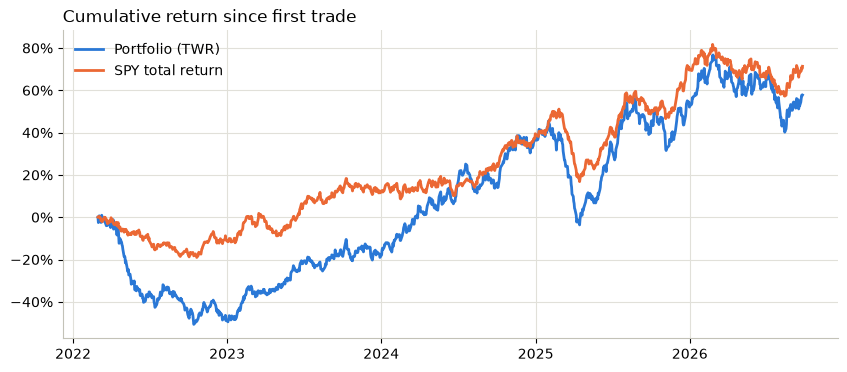

In [3]:
fig, ax = plt.subplots()
ax.plot(pf.index, pf["twr_index"] - 1, color=BLUE, lw=2, label="Portfolio (TWR)")
ax.plot(pf.index, pf["benchmark_index"] - 1, color=ORANGE, lw=2, label=f"{cfg.benchmark} total return")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_title("Cumulative return since first trade", loc="left"); ax.legend(frameon=False)
plt.show()

## 2. Risk-adjusted performance

In [4]:
p, b = pf["daily_return"].iloc[1:], pf["benchmark_return"].iloc[1:]
summary = pd.DataFrame({"Portfolio": metrics.performance_summary(p, b, cfg.risk_free_rate),
                        cfg.benchmark: metrics.performance_summary(b, None, cfg.risk_free_rate)})
summary.style.format("{:.2f}", na_rep="")

,Portfolio,SPY
annual_return,0.11,0.13
annual_volatility,0.25,0.15
sharpe_ratio,0.26,0.59
sortino_ratio,0.37,0.85
max_drawdown,-0.51,-0.23
calmar_ratio,0.21,0.55
var_95,-0.03,-0.01
cvar_95,-0.03,-0.02
beta,1.29,
alpha,-0.05,


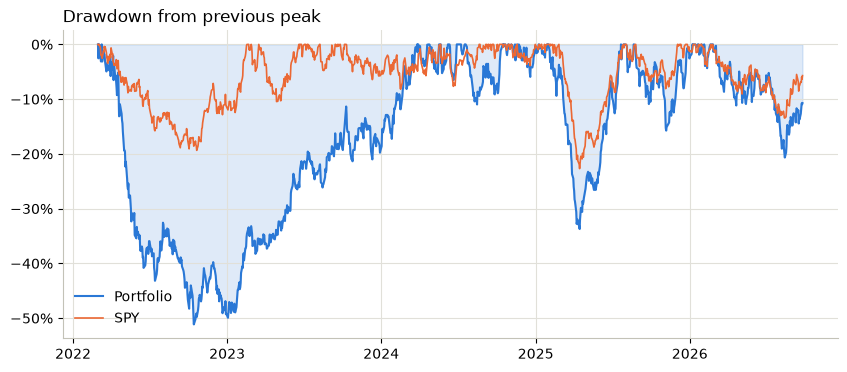

In [5]:
fig, ax = plt.subplots()
ax.fill_between(pf.index, pf["drawdown"], 0, color=BLUE, alpha=0.15)
ax.plot(pf.index, pf["drawdown"], color=BLUE, lw=1.5, label="Portfolio")
bdd = pf["benchmark_index"] / pf["benchmark_index"].cummax() - 1
ax.plot(pf.index, bdd, color=ORANGE, lw=1.2, label=cfg.benchmark)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_title("Drawdown from previous peak", loc="left"); ax.legend(frameon=False)
plt.show()

## 3. Where did the profit come from?

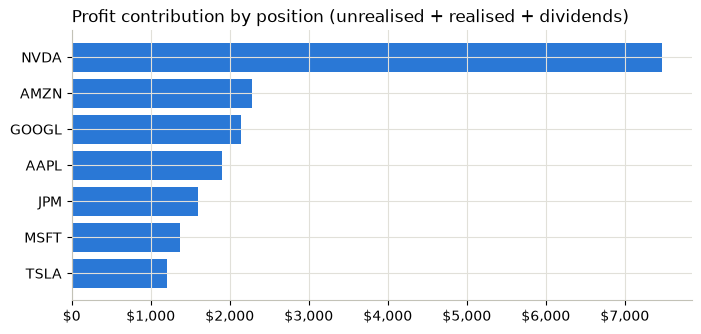

Largest position: NVDA 27% | sector HHI 0.33 (>0.25 = concentrated)


In [6]:
attrib = holdings.assign(total=holdings.unrealized_pnl + holdings.realized_pnl + holdings.dividends_received)
attrib = attrib.sort_values("total")
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.barh(attrib["symbol"], attrib["total"], color=BLUE)
ax.xaxis.set_major_formatter(mtick.StrMethodFormatter("${x:,.0f}"))
ax.set_title("Profit contribution by position (unrealised + realised + dividends)", loc="left")
plt.show()
hhi = (holdings.groupby("sector")["weight"].sum() ** 2).sum()
top = holdings.nlargest(1, "weight").iloc[0]
print(f"Largest position: {top.symbol} {top.weight:.0%} | sector HHI {hhi:.2f} (>0.25 = concentrated)")

## 4. Would a different strategy have done better?

In [7]:
start = pf.index[-1] - pd.DateOffset(years=3)
prices = wh.price_matrix("total_return_index", start=start.date())[holdings["symbol"].tolist()].dropna()
weights = holdings.set_index("symbol")["weight"].to_dict()
table, results = strategies.compare_strategies(prices, weights, 1000)
table.style.format({c: "${:,.0f}" for c in ["total_invested", "final_value", "profit"]}
                   | {c: "{:.1%}" for c in ["twr_annual", "xirr", "max_drawdown", "volatility"]})

,total_invested,final_value,profit,twr_annual,xirr,max_drawdown,volatility
Lump sum (all money on day 1),"$37,000","$86,158","$49,158",32.8%,32.5%,-37.9%,26.5%
"Monthly DCA, never rebalanced","$37,000","$51,948","$14,948",32.4%,22.9%,-35.5%,24.3%
Monthly DCA + quarterly rebalance,"$37,000","$54,869","$17,869",36.1%,26.8%,-33.3%,23.1%


## 5. Findings (computed from the data above)

In [8]:
beat = twr > bench
findings = [
    f"1. Since the first trade the portfolio returned {twr:+.1%} time-weighted vs {bench:+.1%} for {cfg.benchmark} "
    f"-> it {'beat' if beat else 'lagged'} the benchmark by {abs(twr - bench):.1%}.",
    f"2. Money-weighted return (XIRR) is {xirr:.1%}/yr vs a TWR of {headline['TWR (annualised)']:.1%}/yr: "
    + ("timing of deposits helped (more money arrived before strong periods)." if xirr > headline['TWR (annualised)']
       else "timing of deposits hurt (more money arrived before weak periods)."),
    f"3. Risk: Sharpe {summary.loc['sharpe_ratio', 'Portfolio']:.2f} vs {summary.loc['sharpe_ratio', cfg.benchmark]:.2f}, "
    f"beta {summary.loc['beta', 'Portfolio']:.2f}, max drawdown {summary.loc['max_drawdown', 'Portfolio']:.0%} "
    f"vs {summary.loc['max_drawdown', cfg.benchmark]:.0%}.",
    f"4. {attrib.iloc[-1].symbol} produced {attrib.iloc[-1].total / attrib.total.sum():.0%} of total profit; "
    f"largest weight is {top.symbol} at {top.weight:.0%} and sector HHI is {hhi:.2f}.",
    f"5. Over the last 3 years with $1,000/month, '{table['final_value'].idxmax()}' ended highest "
    f"(${table['final_value'].max():,.0f} vs ${table['final_value'].min():,.0f} for the lowest).",
]
print("\n".join(findings))

1. Since the first trade the portfolio returned +57.8% time-weighted vs +71.4% for SPY -> it lagged the benchmark by 13.6%.
2. Money-weighted return (XIRR) is 23.0%/yr vs a TWR of 10.5%/yr: timing of deposits helped (more money arrived before strong periods).
3. Risk: Sharpe 0.26 vs 0.59, beta 1.29, max drawdown -51% vs -23%.
4. NVDA produced 42% of total profit; largest weight is NVDA at 27% and sector HHI is 0.33.
5. Over the last 3 years with $1,000/month, 'Lump sum (all money on day 1)' ended highest ($86,158 vs $51,948 for the lowest).


## 6. Recommendations & caveats

**Recommendations to test next** (each is a question the dashboard's Strategy Lab can answer):
- If one position is well above 25% of the portfolio, set a rebalancing rule (e.g. trim above 30%).
- If beta is well above 1 and drawdowns deeper than the benchmark, the extra risk should be paid for
  by a higher Sharpe ratio. If it is not, a core index holding lowers risk without giving up return.
- Compare XIRR with TWR every quarter: a persistent gap means contribution timing matters more than stock picks.

**Caveats.**
- Past returns do not predict future returns; the efficient frontier and Monte Carlo use history only.
- Dividends are counted as cash (not reinvested) at portfolio level; per-ticker metrics reinvest them.
- Cost basis uses the average-cost method; tax lots (FIFO) would change realised P&L.
- Sample mode prices are synthetic.